# Churn Prediction: Rules of ML Demo

Este notebook muestra dos ideas de produccion:
1. Un baseline simple puede rendir similar a un modelo mas complejo.
2. Drift y training/serving skew degradan performance.

## Contexto
Caso de uso: customer churn prediction (usuarios que abandonan el servicio).

## Paso 1: setup de datos y funciones

Semilla fija para resultados estables en vivo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42


def create_churn_training_data(seed=RANDOM_SEED):
    # Synthetic customer data for churn prediction.
    X, y = make_classification(
        n_samples=2200,
        n_features=8,
        n_informative=6,
        n_redundant=2,
        n_clusters_per_class=1,
        class_sep=1.9,
        flip_y=0.02,
        random_state=seed,
    )
    return X, y


def simulate_production_drift(X, y, seed=RANDOM_SEED, label_flip_rate=0.07):
    rng = np.random.default_rng(seed)
    X_drift = X.copy()

    # Behavior change over time (freshness issue).
    X_drift[:, 1] += 1.0
    X_drift[:, 2] *= 0.7
    X_drift[:, 4] += 0.8
    X_drift[:, 7] *= 0.75

    # Training/serving skew from upstream feature scaling change.
    X_drift[:, 3] *= 1.25
    X_drift += rng.normal(0.0, 0.35, size=X_drift.shape)

    y_drift = y.copy()
    flip_mask = rng.random(y_drift.shape[0]) < label_flip_rate
    y_drift[flip_mask] = 1 - y_drift[flip_mask]

    return X_drift, y_drift

What is being tested: can a simple baseline perform similarly to a complex model?
Accuracy Logistic Regression: 0.988
Accuracy Random Forest:      0.979
Gap (complex - simple):      -0.009


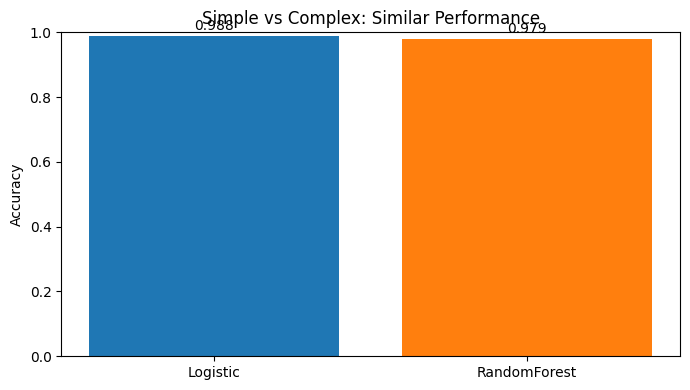

Notice: The complex model does NOT significantly outperform the simple one.
Rule #4: Keep the first model simple and iterate fast.


In [ ]:
# Demo 1: simple vs complex on churn prediction
X, y = create_churn_training_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)

simple_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
complex_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

simple_model.fit(X_train, y_train)
complex_model.fit(X_train, y_train)

simple_acc = accuracy_score(y_test, simple_model.predict(X_test))
complex_acc = accuracy_score(y_test, complex_model.predict(X_test))
gap = complex_acc - simple_acc

print(f"Demo 1 - Logistic Regression accuracy: {simple_acc:.3f}")
print(f"Demo 1 - Random Forest accuracy:      {complex_acc:.3f}")
print(f"Demo 1 - Gap (complex - simple):      {gap:+.3f}")

plt.figure(figsize=(7, 4))
bars = plt.bar(["Logistic", "RandomForest"], [simple_acc, complex_acc], color=["#1f77b4", "#ff7f0e"])
plt.ylim(0.0, 1.0)
plt.ylabel("Accuracy")
plt.title("Simple vs Complex Model (Churn Prediction)")
for b, v in zip(bars, [simple_acc, complex_acc]):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

print("Simple model performs similarly and is easier to debug -> aligns with Rule #4 and #14")

## Paso 2: drift en produccion

El mismo modelo se evalua en:
- Dataset A: distribucion de entrenamiento
- Dataset B: nueva distribucion de clientes + skew de features

In [ ]:
# Demo 2: degradation after production drift
model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train, y_train)

acc_a = accuracy_score(y_test, model.predict(X_test))
X_test_drift, y_test_drift = simulate_production_drift(X_test, y_test)
acc_b = accuracy_score(y_test_drift, model.predict(X_test_drift))

drop = acc_a - acc_b

print(f"Demo 2 - Accuracy before drift: {acc_a:.3f}")
print(f"Demo 2 - Accuracy after drift:  {acc_b:.3f}")
print(f"Demo 2 - Performance drop:      {drop:.3f}")

What is being tested: same model, new production distribution.
Accuracy on Dataset A:       0.988
Accuracy on Dataset B drift: 0.871
Performance drop:            0.117


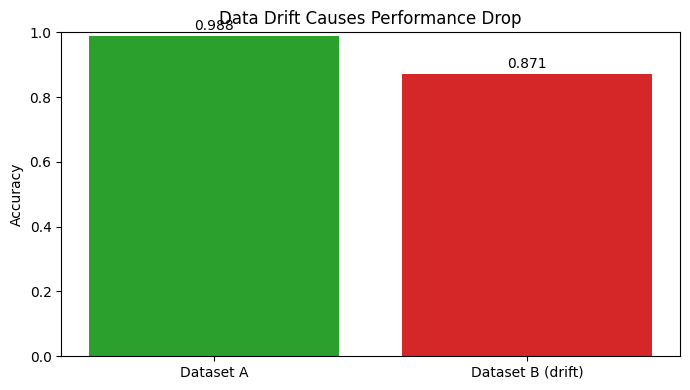

Notice: Performance drops sharply under drift.
Rule #8 / #37: Production data shifts, so monitor and retrain.


In [ ]:
# Visual summary
plt.figure(figsize=(7, 4))
bars = plt.bar(["Dataset A", "Dataset B (drift)"], [acc_a, acc_b], color=["#2ca02c", "#d62728"])
plt.ylim(0.0, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Degradation After Data Drift")
for b, v in zip(bars, [acc_a, acc_b]):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

print("Model performance drops due to data drift -> aligns with Rule #8 and #37")

## Conclusiones

- Empezar con un baseline simple acelera iteracion y debugging.
- Un modelo que funciona hoy puede degradarse con drift de datos.
- Monitorear performance en produccion es obligatorio.